## Analyze and plot results for networks

This script takes in the results from run_over_regs.sh, assembles them into a single dataset, and performs analyses on the data.

In [83]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import numpy as np
import pandas as pd
import os

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

In [85]:
sim_kind = 'agent'
infection_type = 'prim'
d = '/mmfs1/home/oukogu/github/infoimmune/opt_nets/'

nets = []

for f in tqdm(os.listdir(d)):
    if '1000' not in f or infection_type not in f:
        continue
    filepath = os.path.join(d, f)
    nets.append(np.load(filepath))
    
net_data = np.vstack(nets)
print(net_data.shape)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2181/2181 [00:00<00:00, 19497.50it/s]

(729, 33)


In [86]:
# Code for debugging
all_combs = []
for i in range(729):
    str_num = np.base_repr(i, base=3)
    if len(str_num) != 6:
        str_num = '0'*(6 - len(str_num)) + str_num
    all_combs.append(str_num)
    
file_nums = []
for f in sorted(os.listdir(d)):
    if 'sec' not in f:
        continue
    num = ''.join(f.split('-')[:6])
    num = num.partition('.')[0]
    file_nums.append(num)
    
file_nums = set(file_nums)
all_combs = set(all_combs)

stuff = sorted(list(all_combs.difference(file_nums)))

thing = 0
for s in stuff:
    thing = 0
    for idx, i in enumerate(s[::-1]):
        thing += int(i)*3**idx
    print(thing)

30
54
57
58
436


#### (1) Plot ranking MI of networks

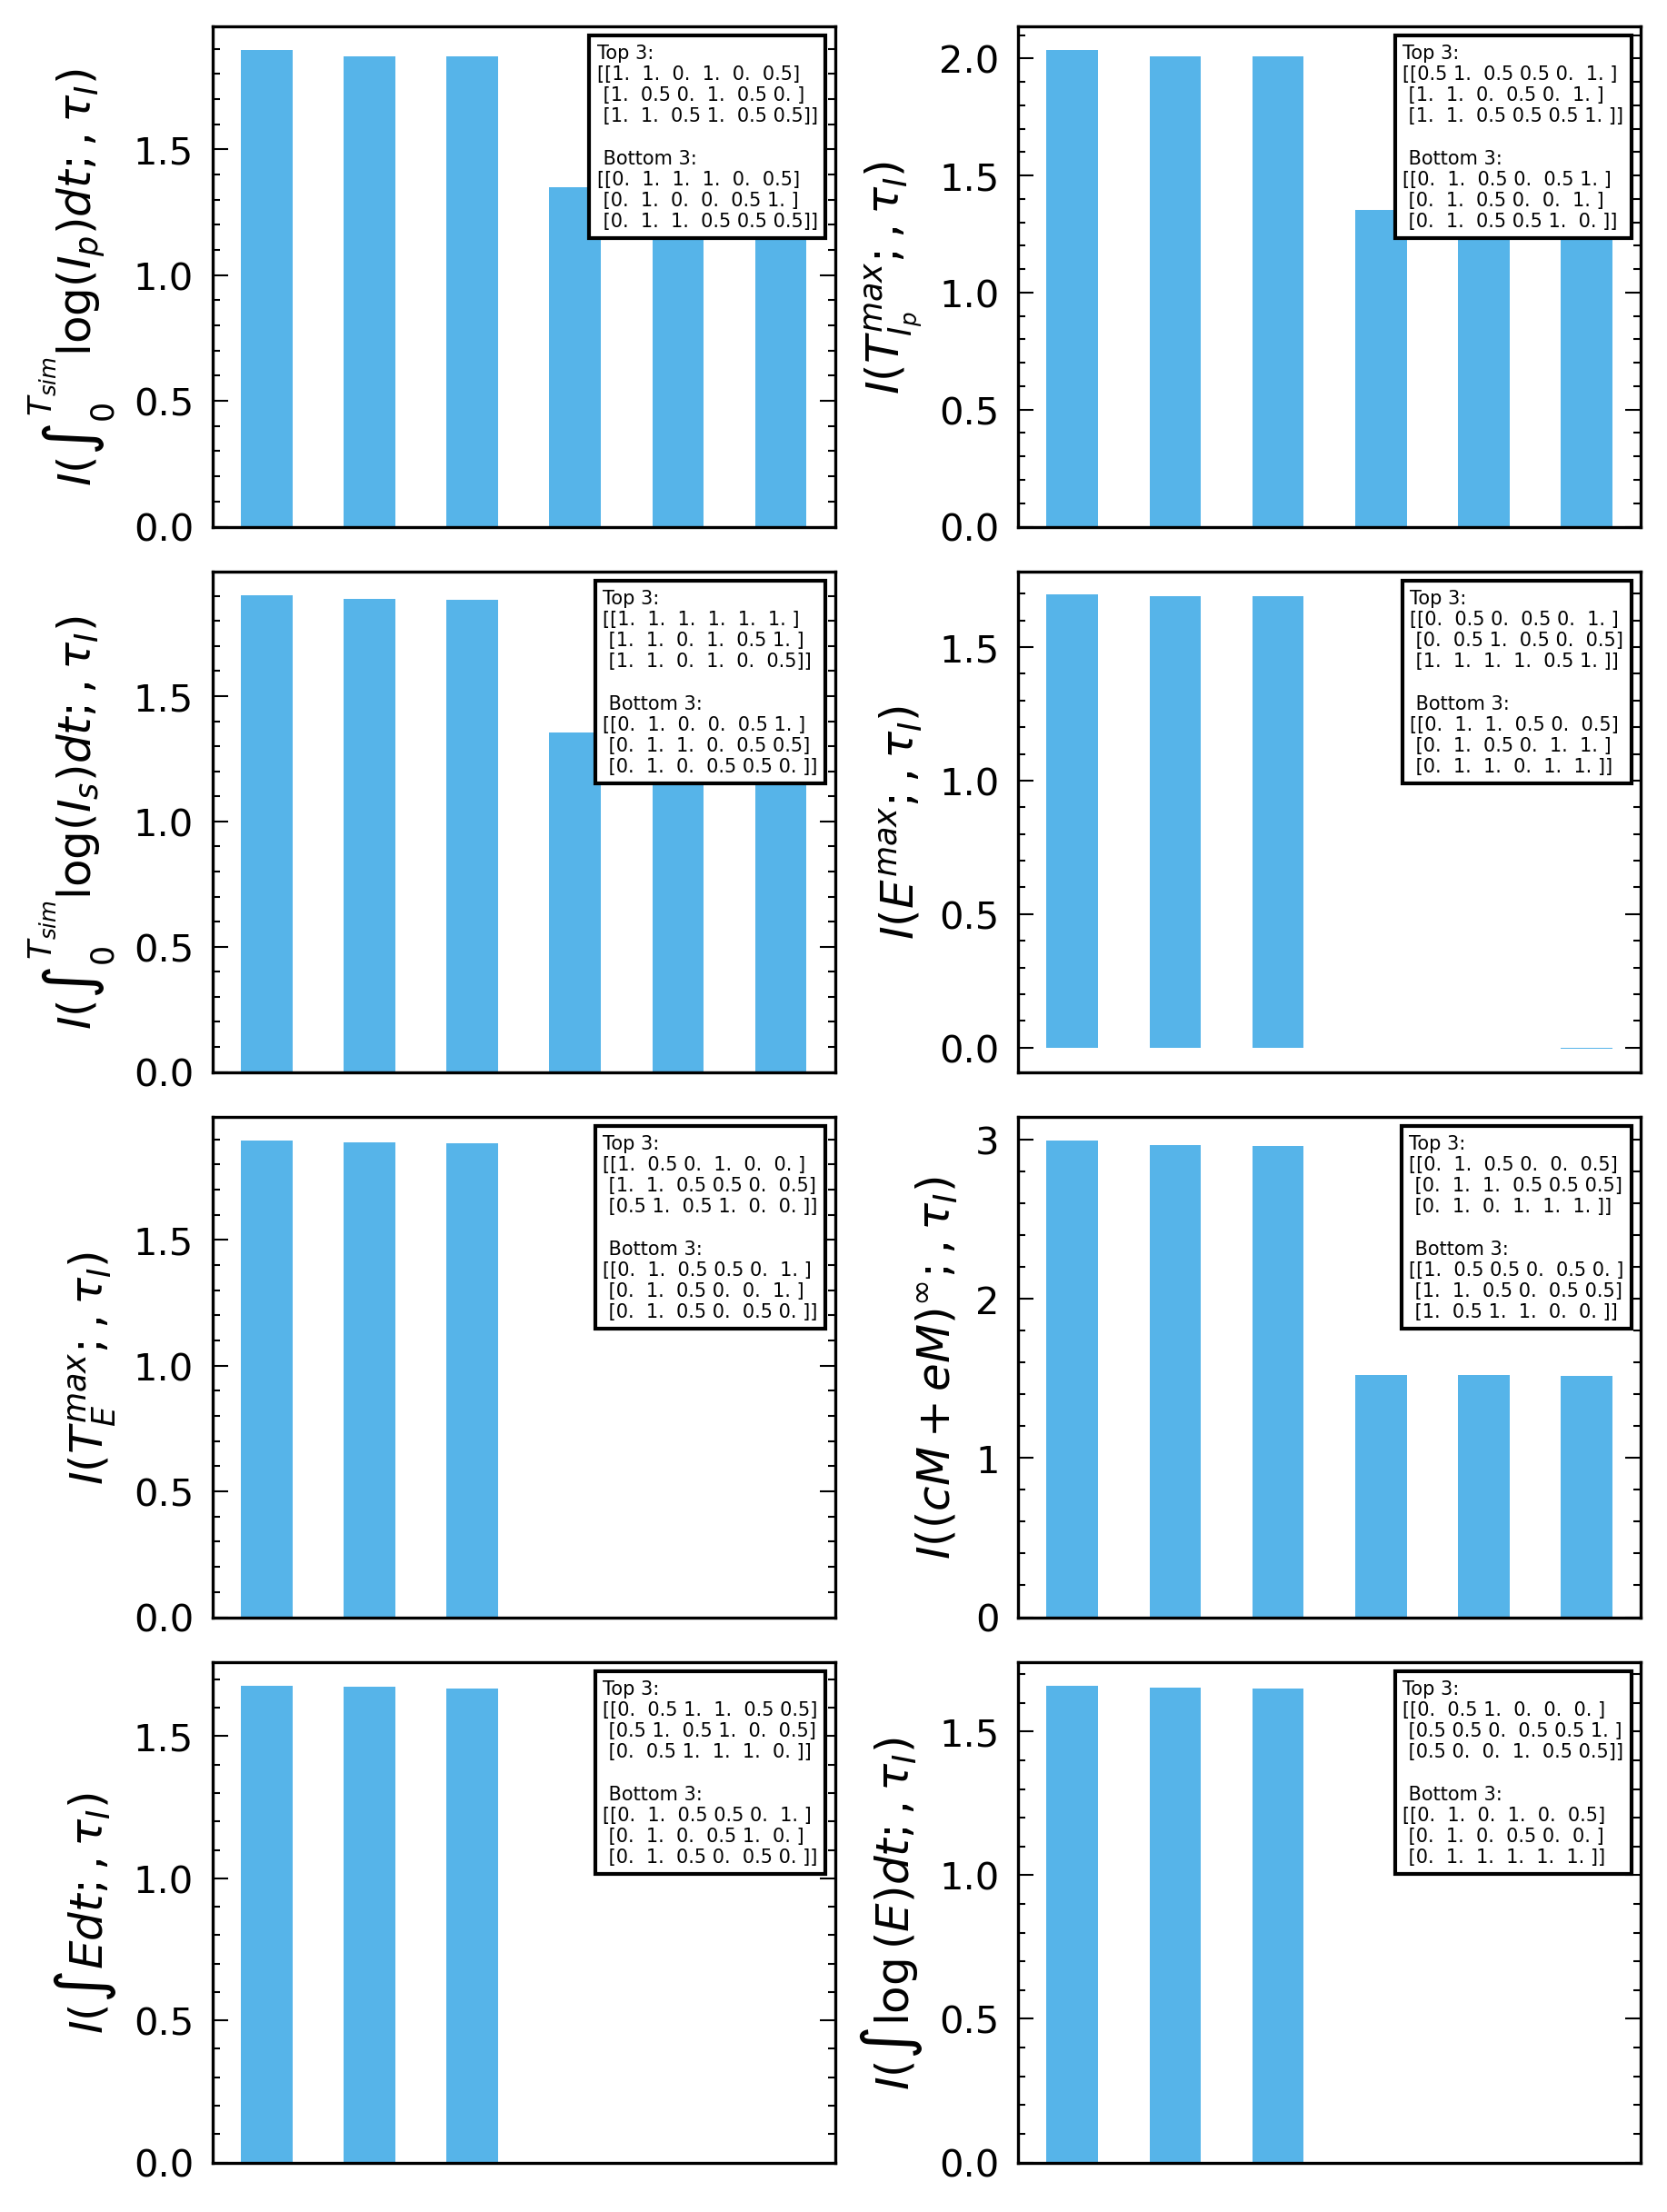

In [87]:
# Plot ranking MI of networks
from matplotlib.offsetbox import AnchoredText
fig_networks, axs = plt.subplots(4,2, dpi = 150, constrained_layout = True, figsize = (6,8))
i = 6

for ax, val in zip(axs.flat,stat_names[10:]):
    
    rank_net = net_data[(-net_data[:, i]).argsort()]
    anchored_text = AnchoredText("Top 3: \n"+str(np.round_(rank_net[:3,0:6],2))+"\n\n Bottom 3: \n"+str(np.round_(rank_net[-4:-1,0:6],2)), 
                                 prop=dict(size=5), loc = "upper right")
    
    r = np.arange(6)
    width = 0.5
    ax.bar(r, np.append(rank_net[0:3,i], rank_net[-4:-1,i], axis = 0), width = width, label = r'vary $\tau_I$')

    ax.set(ylabel = r"$I($"+val+r"$;,\tau_I)$")
    ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    ax.add_artist(anchored_text)
    
    #ax.set_title(plot_title, fontsize = 5)
    i += 1

    #ax.semilogy()
    #plt.legend()
#fig_networks.suptitle(r'Optimal networks for information processing $(\psi_{N}^{(I)},\psi_{N}^{(c)},\psi_{cM}^{(I)},\psi_{cM}^{(c)}, \psi_{E}^{(I)}, \psi_{E}^{(c)})$'+' for '+infection_type+". infection")
#fig_networks.savefig("_figs/"+sim_kind+'-'+infection_type+'-'+'rank-optimal-nets-for-info'+str(tau_I)+'.png', dpi=150)

([], [])

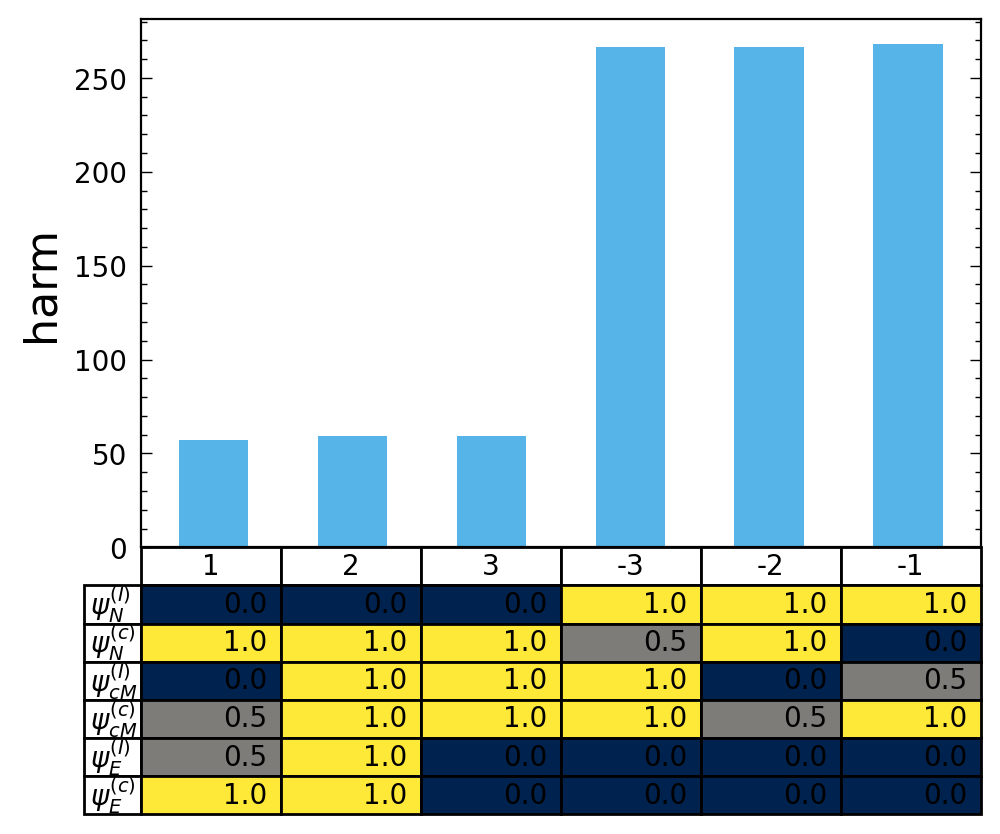

In [88]:
# plot ranking of networks based on effectiveness
eff_rank_net = net_data[(net_data[:, -7]).argsort()]

plt.figure(figsize=(6,3))
r = np.arange(6)
width = 0.5

opt_regs = np.round_(np.vstack((eff_rank_net[-4:-1,0:6], eff_rank_net[:3,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, np.append(eff_rank_net[0:3,-7], eff_rank_net[-4:-1,-7],  axis = 0), width = width, label = r'vary $\tau_I$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N}^{(I)}$", r"$\psi_{N}^{(c)}$", r"$\psi_{cM}^{(I)}$", r"$\psi_{cM}^{(c)}$", r"$\psi_{E}^{(I)}$", r"$\psi_{E}^{(c)}$"],
                      colLabels=[1,2,3, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel(r"$\mathbb{E}[$"+stat_names[10]+r"$]$", fontsize = 16)
plt.ylabel("harm", fontsize = 16)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])
#plt.colorbar(the_table, shrink=0.5, aspect=10, label =r"$\psi$")

#plt.savefig("_figs/"+sim_kind+'-'+infection_type+'-'+'rank-optimal-nets-for-eff'+'.png', dpi=300, bbox_inches="tight")

([], [])

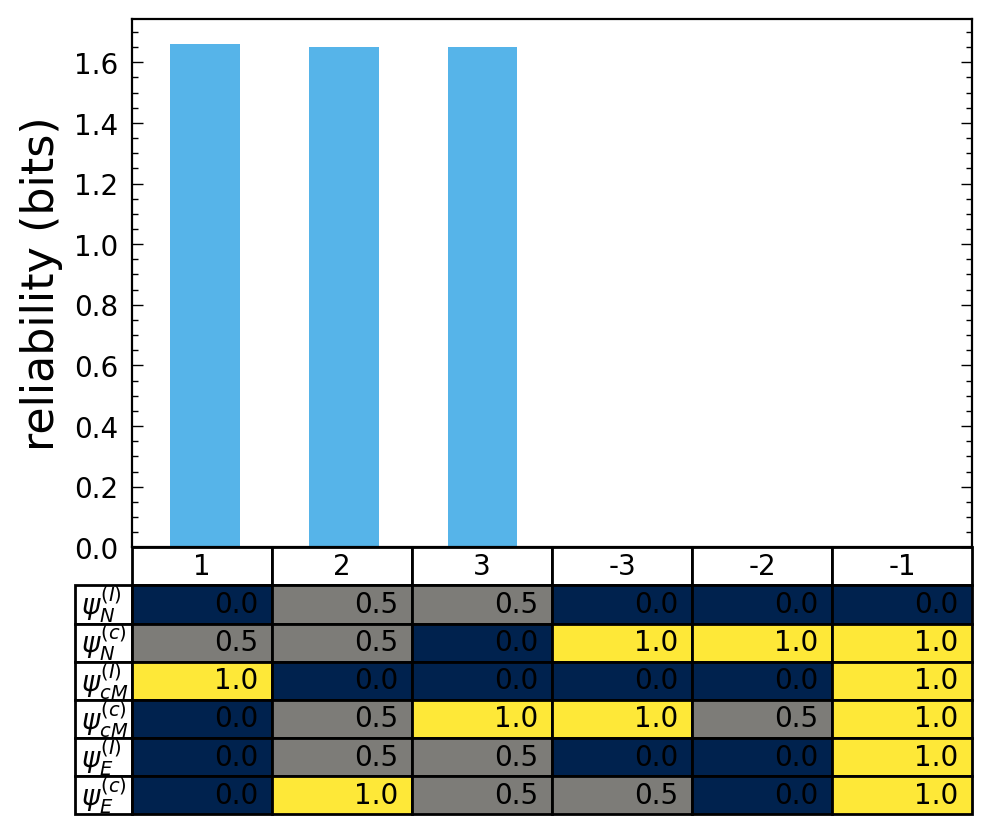

In [89]:
# plot ranking of networks based on mutual information between effector response
eff_rank_net = net_data[(-net_data[:, 13]).argsort()]

plt.figure(figsize=(6,3))  
r = np.arange(6)
width = 0.5
opt_regs = np.round_(np.vstack((eff_rank_net[:3,0:6], eff_rank_net[-4:-1,0:6])),2).T
norm = plt.Normalize(opt_regs.min(), opt_regs.max())
colours = plt.cm.cividis(norm(opt_regs))

plt.bar(r, np.append(eff_rank_net[0:3,13], eff_rank_net[-4:-1,13], axis = 0), width = width, label = r'vary $\tau_I$')

the_table = plt.table(cellText= opt_regs,
                      rowLabels=[r"$\psi_{N}^{(I)}$", r"$\psi_{N}^{(c)}$", r"$\psi_{cM}^{(I)}$", r"$\psi_{cM}^{(c)}$", r"$\psi_{E}^{(I)}$", r"$\psi_{E}^{(c)}$"],
                      colLabels=[1,2,3, -3,-2,-1],
                      loc='bottom',
                      cellColours = colours)

plt.subplots_adjust(left=0.2, bottom=0.0)
#plt.ylabel( r"$I($"+stat_names[16]+r";$\tau_I)$", fontsize = 16)
plt.ylabel("reliability (bits)", fontsize = 16)
#plt.xlabel('rank', fontsize = 16)
plt.xticks([])


#plt.savefig("_figs/"+sim_kind+'-'+infection_type+'-'+'rank-optimal-nets-for-rel-E'+'.png', dpi=300, bbox_inches="tight")

In [90]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 600)

i = 0

for val in stat_names[i+10:]:

    xy = np.array([net_data[:,i+6] ,net_data[:,-7]]).T
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(5, 2, i+1)
    cs = ax.scatter(xy[:,0], xy[:,1], c='#969696')
    
    # find pareto front
    remove_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                remove_row[j] = False
                
    
    x_front = (xy[:,0])[remove_row,...]
    y_front = (xy[:,1])[remove_row,...]
    ax.scatter(x_front, y_front, c='#252525')
    
    ax.axis([0.0, np.max(xy[:,0])*1.15, 0.95*np.min(xy[:,1]), np.max(xy[:,1])*1.15])
    # for k in np.arange(0,len(x_front)):
    #     ax.text(x_front[k],y_front[k], k, ha="center", va="center")
    
    # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
    axins = inset_axes(ax, width="25%", height="25%", loc=2, borderpad = 3.2)
    axins.scatter(net_data[remove_row,4], net_data[remove_row,5], c ='#252525')
    axins.scatter(net_data[np.argmin(xy[:,1]),4], net_data[np.argmin(xy[:,1]),5], c ='#e34a33')
    axins.scatter(net_data[np.argmax(xy[:,0]),4], net_data[np.argmax(xy[:,0]),5], c = '#6baed6')
    axins.set(xlabel=r'$\psi_E^{(I)}$', ylabel=r'$\psi_E^{(c)}$')
    axins.axis([-0.05, 1.05, -0.05, 1.05])

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$\tau_I)$", ylabel=r"$\mathbb{E}_{\sim \tau_I, b_I}[$"+stat_names[10]+r"$]$")
    #ax.set(xlabel="reliability with antigenicity (bits)", ylabel="harm")
    
    i += 1
    
#fig_b_I.suptitle(r'Pareto front over $(\psi_{N}^{(I)},\psi_{N}^{(c)},\psi_{cM}^{(I)},\psi_{cM}^{(c)}, \psi_{E}^{(I)}, \psi_{E}^{(c)})$'+' for '+infection_type+". infection")
#fig_b_I.savefig("_figs/"+sim_kind+'-'+infection_type+'-pareto-over-all-antigenicity.png', dpi=600)#, bbox_inches="tight")
plt.tight_layout()

plt.show()

/tmp/ipykernel_16564/3557137260.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/tmp/ipykernel_16564/3889168369.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


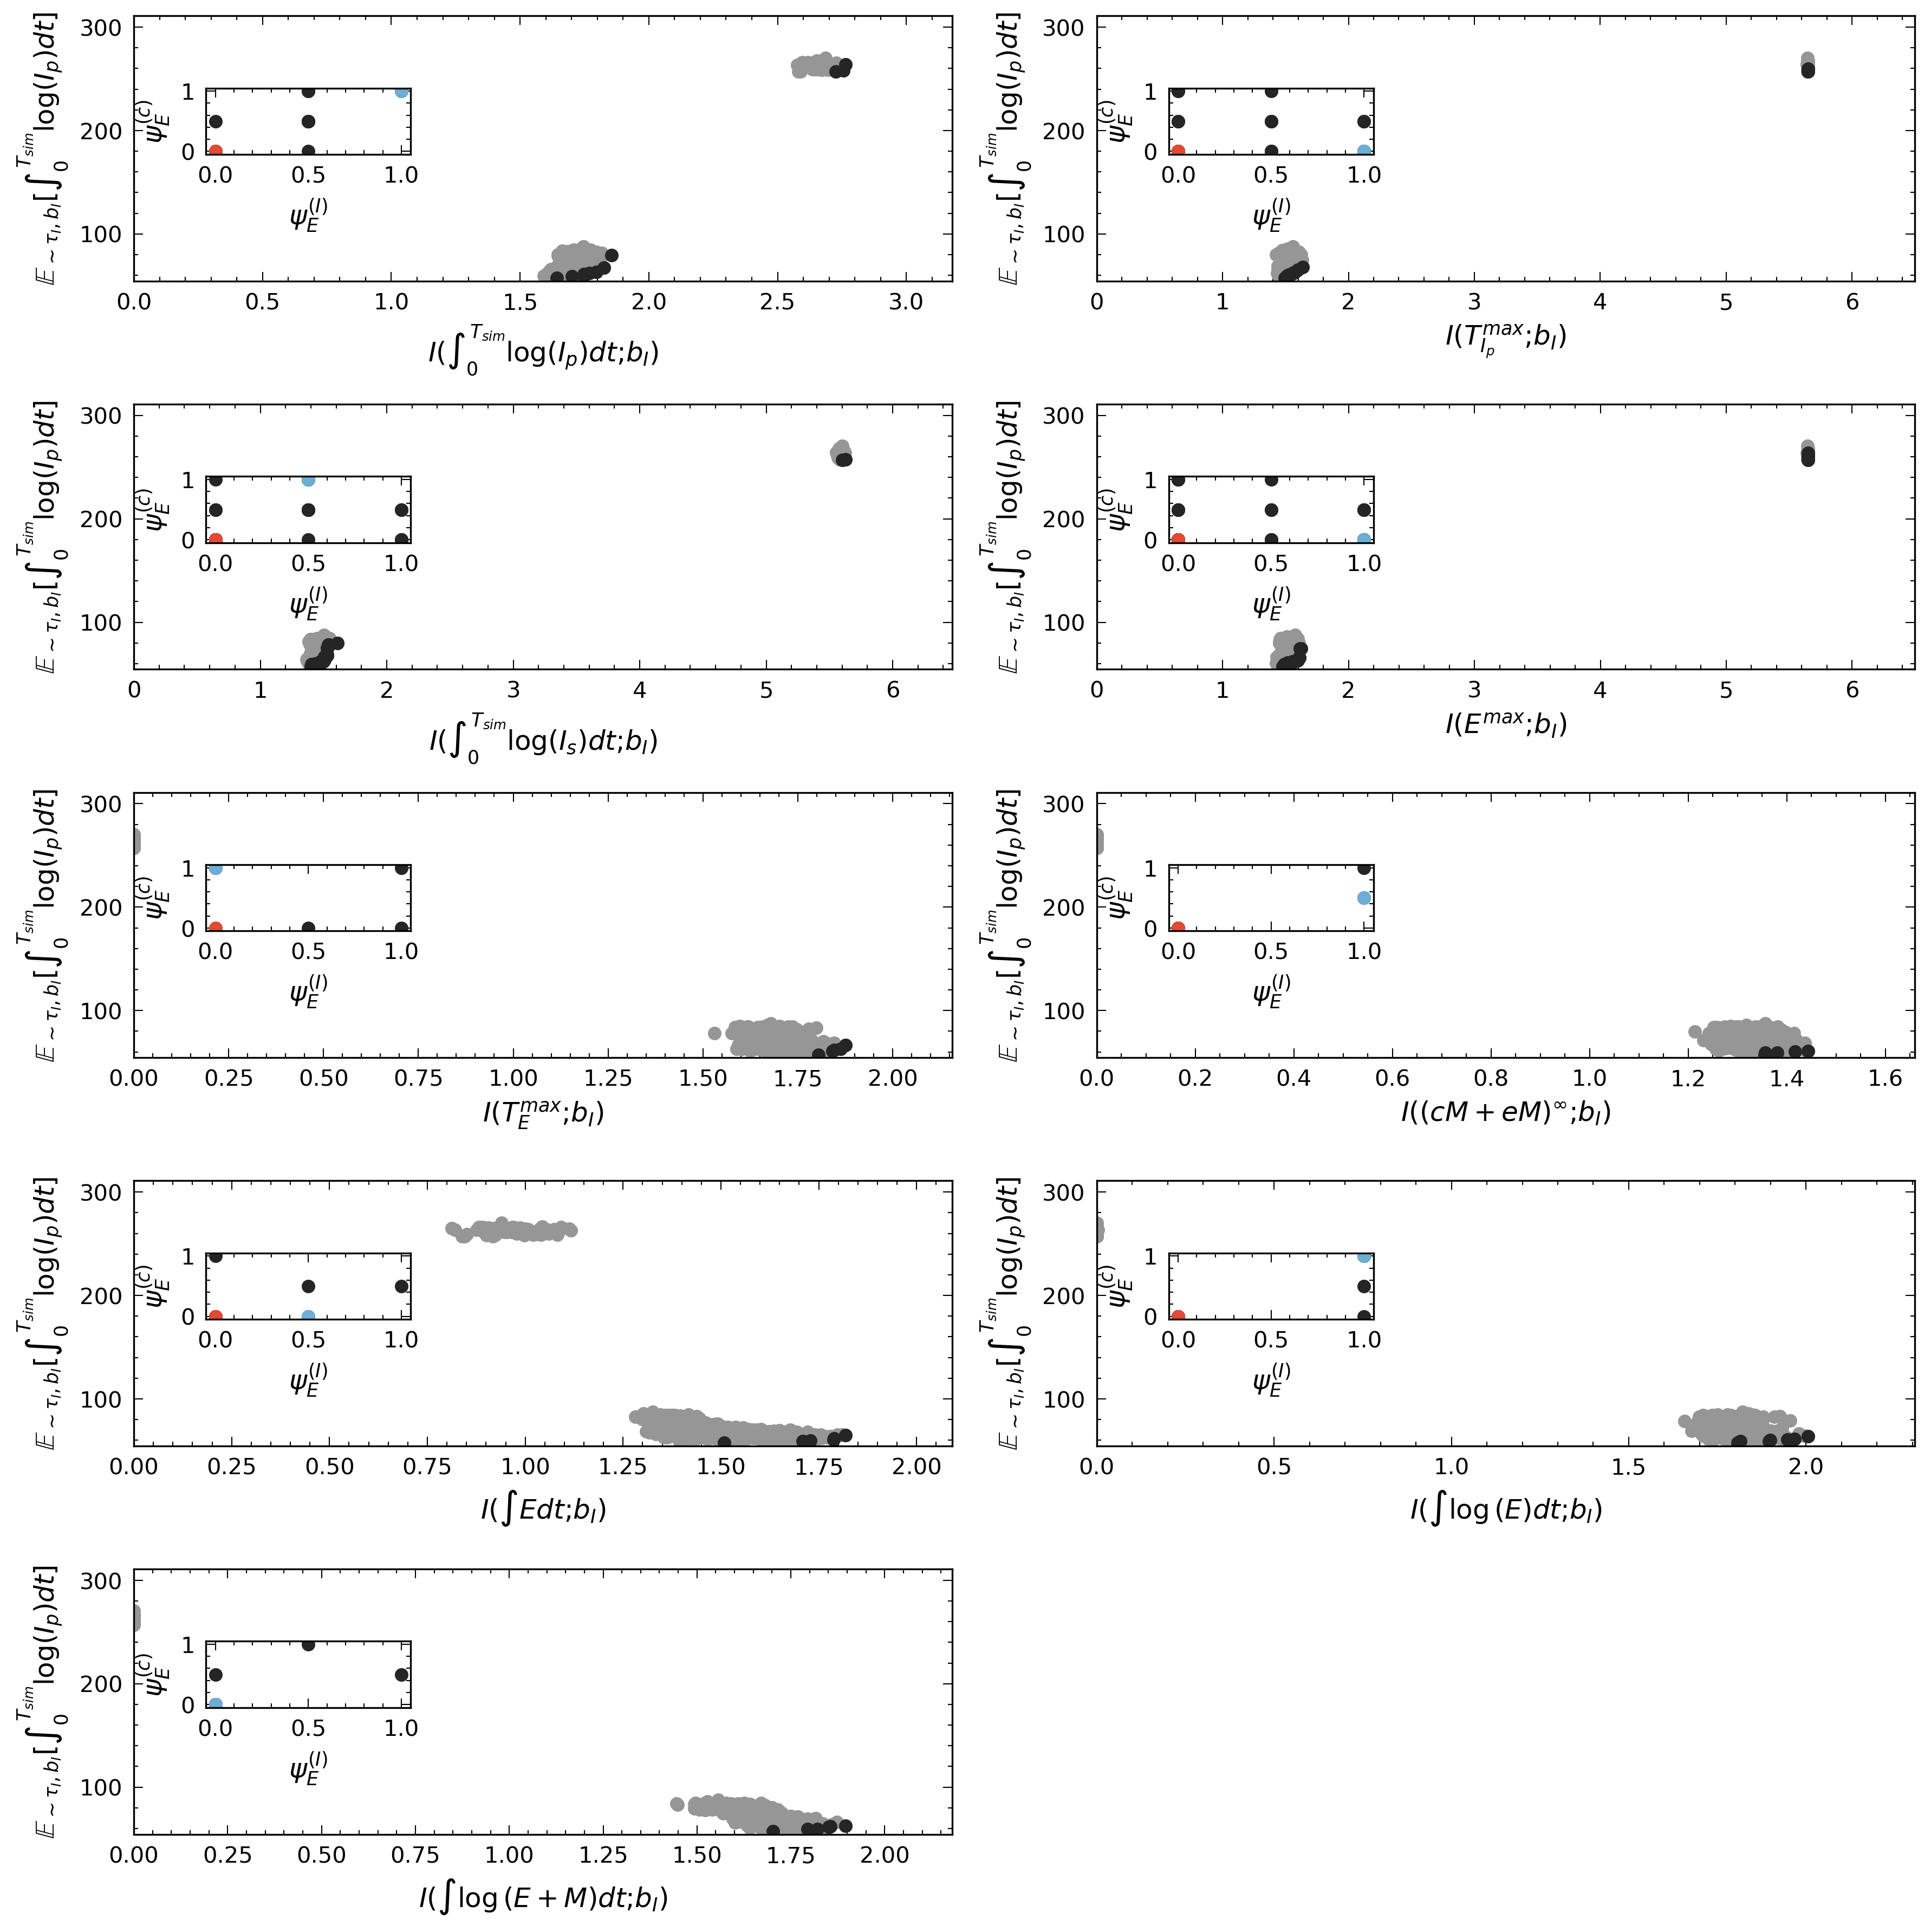

In [91]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 0

for val in stat_names[i+10:]:

    xy = np.array([net_data[:,i+14],net_data[:,-7]]).T
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(5, 2, i+1)
    cs = ax.scatter(xy[:,0], xy[:,1], c='#969696')
    
    # find pareto front
    remove_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                remove_row[j] = False
                
    
    x_front = (xy[:,0])[remove_row,...]
    y_front = (xy[:,1])[remove_row,...]
    ax.scatter(x_front, y_front, c='#252525')
    
    ax.axis([0.0, np.max(xy[:,0])*1.15, 0.95*np.min(xy[:,1]), np.max(xy[:,1])*1.15])
    # for k in np.arange(0,len(x_front)):
    #     ax.text(x_front[k],y_front[k], k, ha="center", va="center")
    
    # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
    axins = inset_axes(ax, width="25%", height="25%", loc=2, borderpad = 3.2)
    axins.scatter(net_data[remove_row,4], net_data[remove_row,5], c ='#252525')
    axins.scatter(net_data[np.argmin(xy[:,1]),4], net_data[np.argmin(xy[:,1]),5], c ='#e34a33') #effectiveness
    axins.scatter(net_data[np.argmax(xy[:,0]),4], net_data[np.argmax(xy[:,0]),5], c = '#6baed6') # responsiveness
    axins.set(xlabel=r'$\psi_E^{(I)}$', ylabel=r'$\psi_E^{(c)}$')
    axins.axis([-0.05, 1.05, -0.05, 1.05])

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$b_I)$", ylabel=r"$\mathbb{E}_{\sim \tau_I, b_I}[$"+stat_names[10]+r"$]$")
    #ax.set(xlabel="reliability with virulence (bits)", ylabel="harm")
    
    i += 1
    
#fig_b_I.suptitle(r'Pareto front over $(\psi_{N}^{(I)},\psi_{N}^{(c)},\psi_{cM}^{(I)},\psi_{cM}^{(c)}, \psi_{E}^{(I)}, \psi_{E}^{(c)})$'+' for '+infection_type+". infection")
#fig_b_I.savefig("_figs/"+sim_kind+'-'+infection_type+'-pareto-over-all-virulence.png', dpi=600)#, bbox_inches="tight")
plt.tight_layout()

plt.show()